# exp1

   Age  %Fat
0   23   7.8
1   23   9.5
2   27  17.8
3   27  25.9
4   39  26.5
Mean: 46.44444444444444
Median: 51.0
Mode: 23
Std: 13.218624215242329
Var: 174.73202614379088
Range: 38


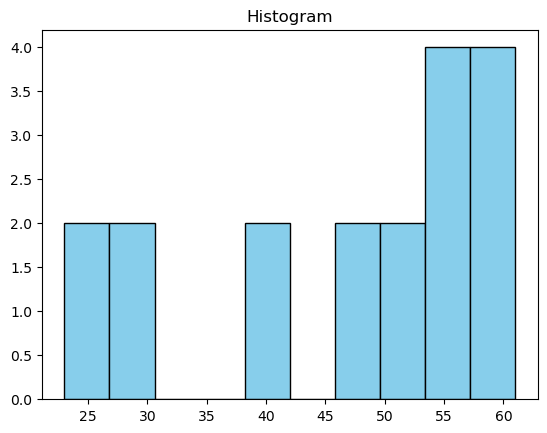

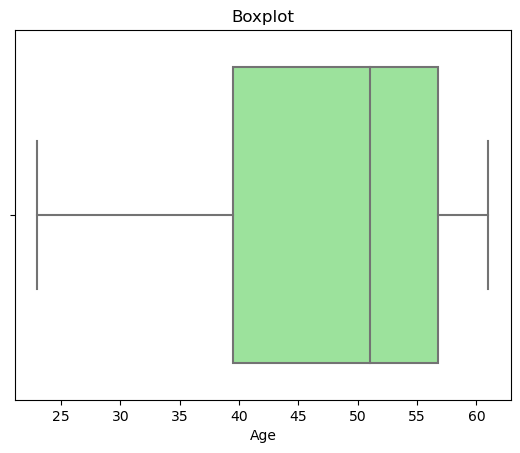

Outliers: []
G
Old      9
Mid      5
Young    4
Name: count, dtype: int64


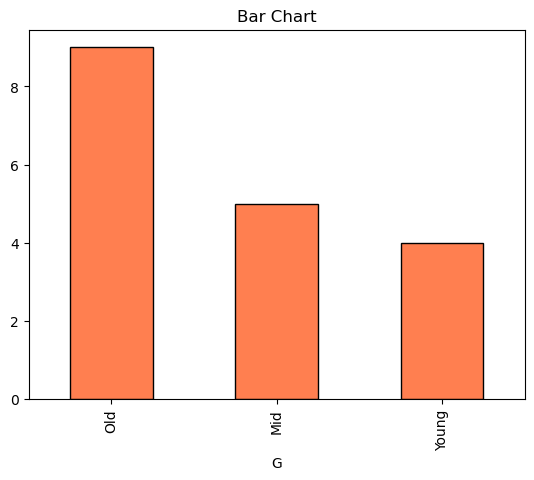

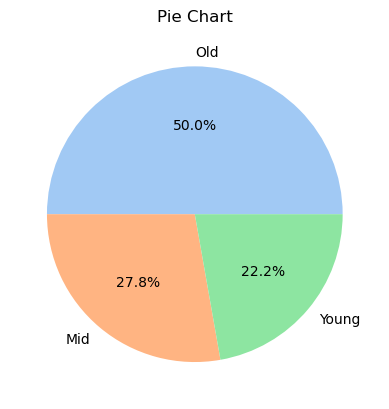

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data
d = pd.DataFrame({'Age':[23,23,27,27,39,41,47,49,50,52,54,54,56,57,58,58,60,61],
                  '%Fat':[7.8,9.5,17.8,25.9,26.5,27.2,27.4,28.8,30.2,31.2,31.4,32.9,33.4,34.1,34.6,35.7,41.2,42.5]})
d.to_csv('Age_Fat.csv', index=False)
d = pd.read_csv('Age_Fat.csv')
g = d['Age']

# Stats
print(d.head())
print("Mean:"   , g.mean())
print("Median:" , g.median())
print("Mode:"   , g.mode()[0])
print("Std:"    , g.std())
print("Var:"    , g.var())
print("Range:"  , g.max() - g.min())

# Histogram
plt.hist(g, bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram")
plt.show()

# Boxplot
sns.boxplot(x=g, color='lightgreen')
plt.title("Boxplot")
plt.show()

# Outliers
q1, q3 = g.quantile(0.25), g.quantile(0.75)
iqr = q3 - q1
print("Outliers:", g[(g < q1-1.5*iqr) | (g > q3+1.5*iqr)].values)

# Age Group
d['G'] = d['Age'].apply(lambda x: 'Young' if x<30 else 'Mid' if x<=50 else 'Old')
c = d['G'].value_counts()
print(c)

# Bar Chart
c.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Bar Chart")
plt.show()

# Pie Chart
c.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Pie Chart")
plt.ylabel("")
plt.show()

# exp2

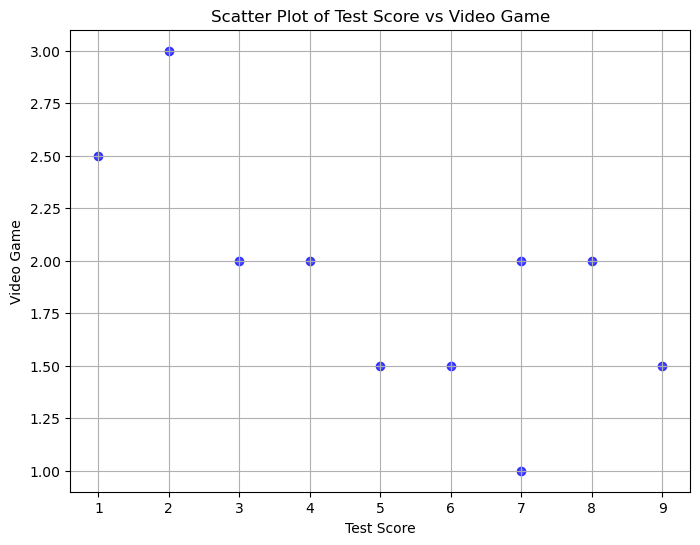

Pearson Correlation: -0.6847868181682677

Covariance Matrix:
[[ 7.06666667 -1.03333333]
 [-1.03333333  0.32222222]]

Correlation Matrix:
            Test Score  Video Game
Test Score    1.000000   -0.684787
Video Game   -0.684787    1.000000


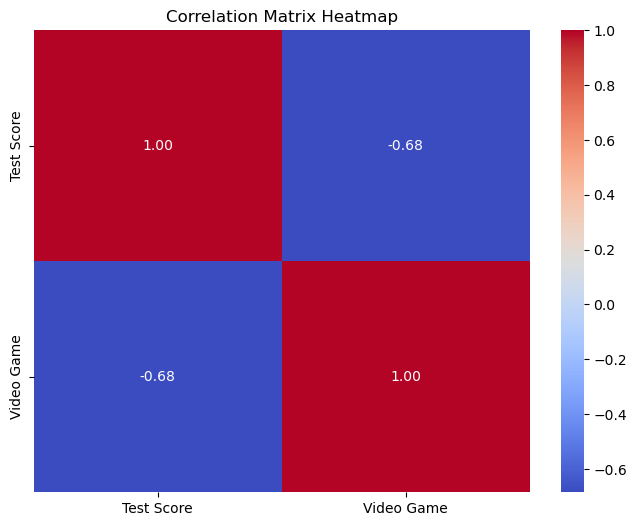

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load Data ─────────────────────────────────────
df = pd.read_csv("Sample_Marks.csv")
c1, c2 = "Test Score", "Video Game"
sel = df[[c1, c2]]

# ── 2. Scatter Plot ───────────────────────────────────
plt.figure(figsize=(8,6))
plt.scatter(sel[c1], sel[c2], color="blue", alpha=0.7)
plt.title(f"Scatter Plot of {c1} vs {c2}")
plt.xlabel(c1)
plt.ylabel(c2)
plt.grid(True)
plt.show()

# ── 3. Pearson Correlation ────────────────────────────
print("Pearson Correlation:", np.corrcoef(sel[c1], sel[c2])[0,1])

# ── 4. Covariance Matrix ──────────────────────────────
print("\nCovariance Matrix:")
print(np.cov(sel[c1], sel[c2]))

# ── 5. Correlation Matrix ─────────────────────────────
corr = sel.corr()
print("\nCorrelation Matrix:")
print(corr)

# ── 6. Heatmap ────────────────────────────────────────
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

# exp5

Predicted Tip for $30 bill: 3.99


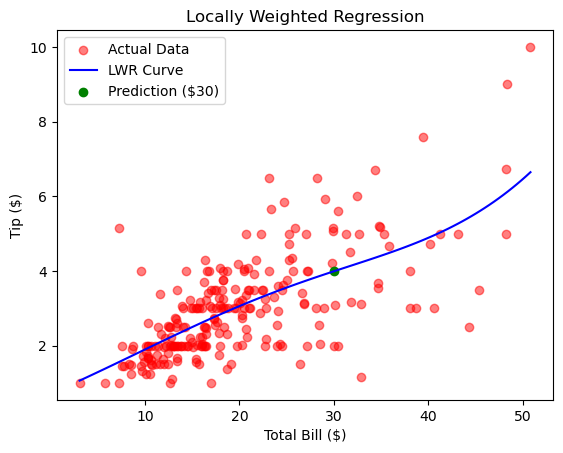

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Load Data ─────────────────────────────────────
tips = pd.read_csv("10-dataset.csv")
X = tips["total_bill"].values
y = tips["tip"].values

# ── 2. Locally Weighted Regression ───────────────────
def lwr(x_q, X, y, tau):
    w     = np.exp(-((X - x_q) ** 2) / (2 * tau ** 2))
    X_b   = np.c_[np.ones(len(X)), X]
    theta = np.linalg.pinv(X_b.T @ np.diag(w) @ X_b) @ (X_b.T @ np.diag(w) @ y)
    return np.array([1, x_q]) @ theta

# ── 3. Predict ────────────────────────────────────────
tau, x_q  = 10, 30
pred      = lwr(x_q, X, y, tau)
print(f"Predicted Tip for $30 bill: {pred:.2f}")

# ── 4. Plot ───────────────────────────────────────────
X_range = np.linspace(X.min(), X.max(), 100)
y_pred  = [lwr(x, X, y, tau) for x in X_range]

plt.scatter(X, y, color='red', alpha=0.5, label="Actual Data")
plt.plot(X_range, y_pred, color='blue', label="LWR Curve")
plt.scatter([x_q], [pred], color='green', marker='o', label="Prediction ($30)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.title("Locally Weighted Regression")
plt.legend()
plt.show()

# exp4

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── 1. Load & Prepare ─────────────────────────────────
df = pd.read_csv('iris.csv')
X  = StandardScaler().fit_transform(df.iloc[:,:-1])
y  = LabelEncoder().fit_transform(df.iloc[:,-1])
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.3,random_state=42)

# ── 2. Evaluate ───────────────────────────────────────
def run(w):
    for k in [1,3,5]:
        p=KNeighborsClassifier(k,weights=w).fit(X_tr,y_tr).predict(X_te)
        print(f"k={k} Acc={accuracy_score(y_te,p):.4f} F1={f1_score(y_te,p,average='weighted'):.4f}")
        print(confusion_matrix(y_te,p))

# ── 3. Run ────────────────────────────────────────────
print("Regular:");  run('uniform')
print("Weighted:"); run('distance')

Regular:
k=1 Acc=0.9778 F1=0.9777
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
k=3 Acc=1.0000 F1=1.0000
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
k=5 Acc=1.0000 F1=1.0000
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Weighted:
k=1 Acc=0.9778 F1=0.9777
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
k=3 Acc=1.0000 F1=1.0000
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
k=5 Acc=1.0000 F1=1.0000
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


# EXP3

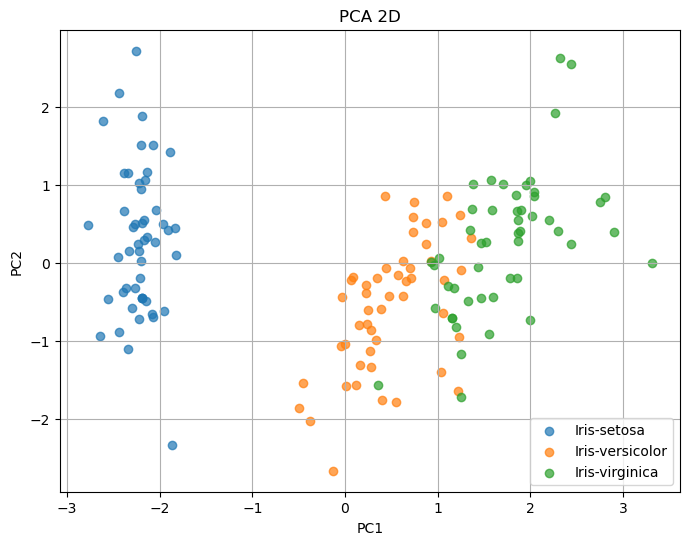

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Original: (150, 4) | Reduced: (150, 2)
Explained Var: [0.72770452 0.23030523]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── 1. Load & Prepare ─────────────────────────────────
df = pd.read_csv('iris.csv')
X, y = df.iloc[:,:-1].values, df.iloc[:,-1].values

# ── 2. Scale & PCA ───────────────────────────────────
X_pca = PCA(n_components=2)
X_t   = X_pca.fit_transform(StandardScaler().fit_transform(X))

# ── 3. Plot & Print ───────────────────────────────────
plt.figure(figsize=(8,6))
[plt.scatter(X_t[y==l,0], X_t[y==l,1], label=l, alpha=0.7) for l in np.unique(y)]
plt.title('PCA 2D'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

print(df.head())
print("Original:", X.shape, "| Reduced:", X_t.shape)
print("Explained Var:", X_pca.explained_variance_ratio_)

# EXP6

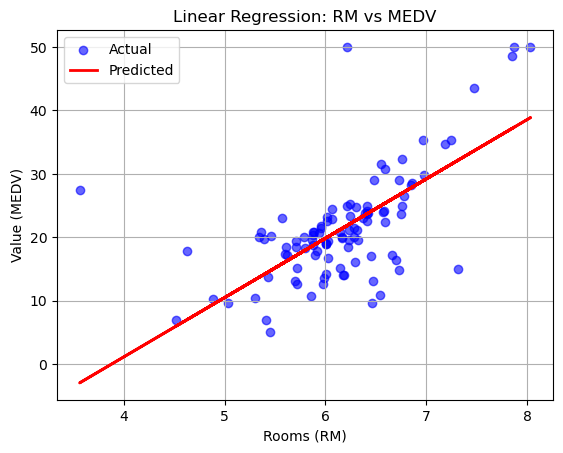

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ── 1. Load & Split ───────────────────────────────────
data = pd.read_csv("BostonHousing.csv")
X, y = data[['rm']], data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Train & Predict ────────────────────────────────
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── 3. Plot ───────────────────────────────────────────
plt.scatter(X_test, y_test, color='blue', label='Actual', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel("Rooms (RM)"); plt.ylabel("Value (MEDV)")
plt.title("Linear Regression: RM vs MEDV")
plt.legend(); plt.grid(True); plt.show()

# exp6

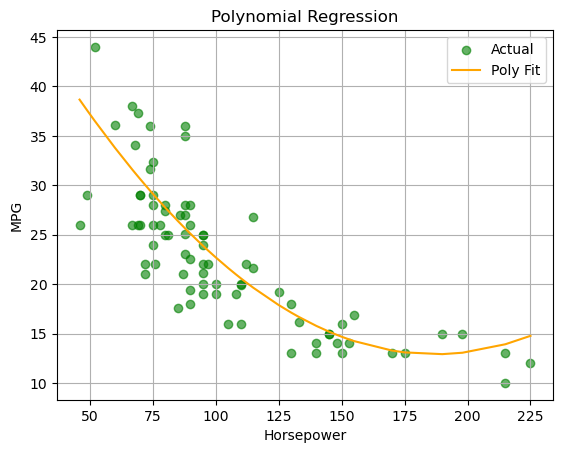

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# ── 1. Load & Clean ───────────────────────────────────
data = pd.read_csv("auto-mpg.csv")
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data.dropna(subset=['horsepower'], inplace=True)

# ── 2. Split & Transform ──────────────────────────────
X, y = data[['horsepower']], data['mpg']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
poly = PolynomialFeatures(degree=2)
X_trp, X_tep = poly.fit_transform(X_tr), poly.transform(X_te)

# ── 3. Train & Plot ───────────────────────────────────
y_pred = LinearRegression().fit(X_trp, y_tr).predict(X_tep)
idx    = X_te['horsepower'].argsort()

plt.scatter(X_te, y_te, color='green', label='Actual', alpha=0.6)
plt.plot(X_te.iloc[idx], y_pred[idx], color='orange', label='Poly Fit')
plt.xlabel("Horsepower"); plt.ylabel("MPG")
plt.title("Polynomial Regression"); plt.legend(); plt.grid(True); plt.show()

# EXP7

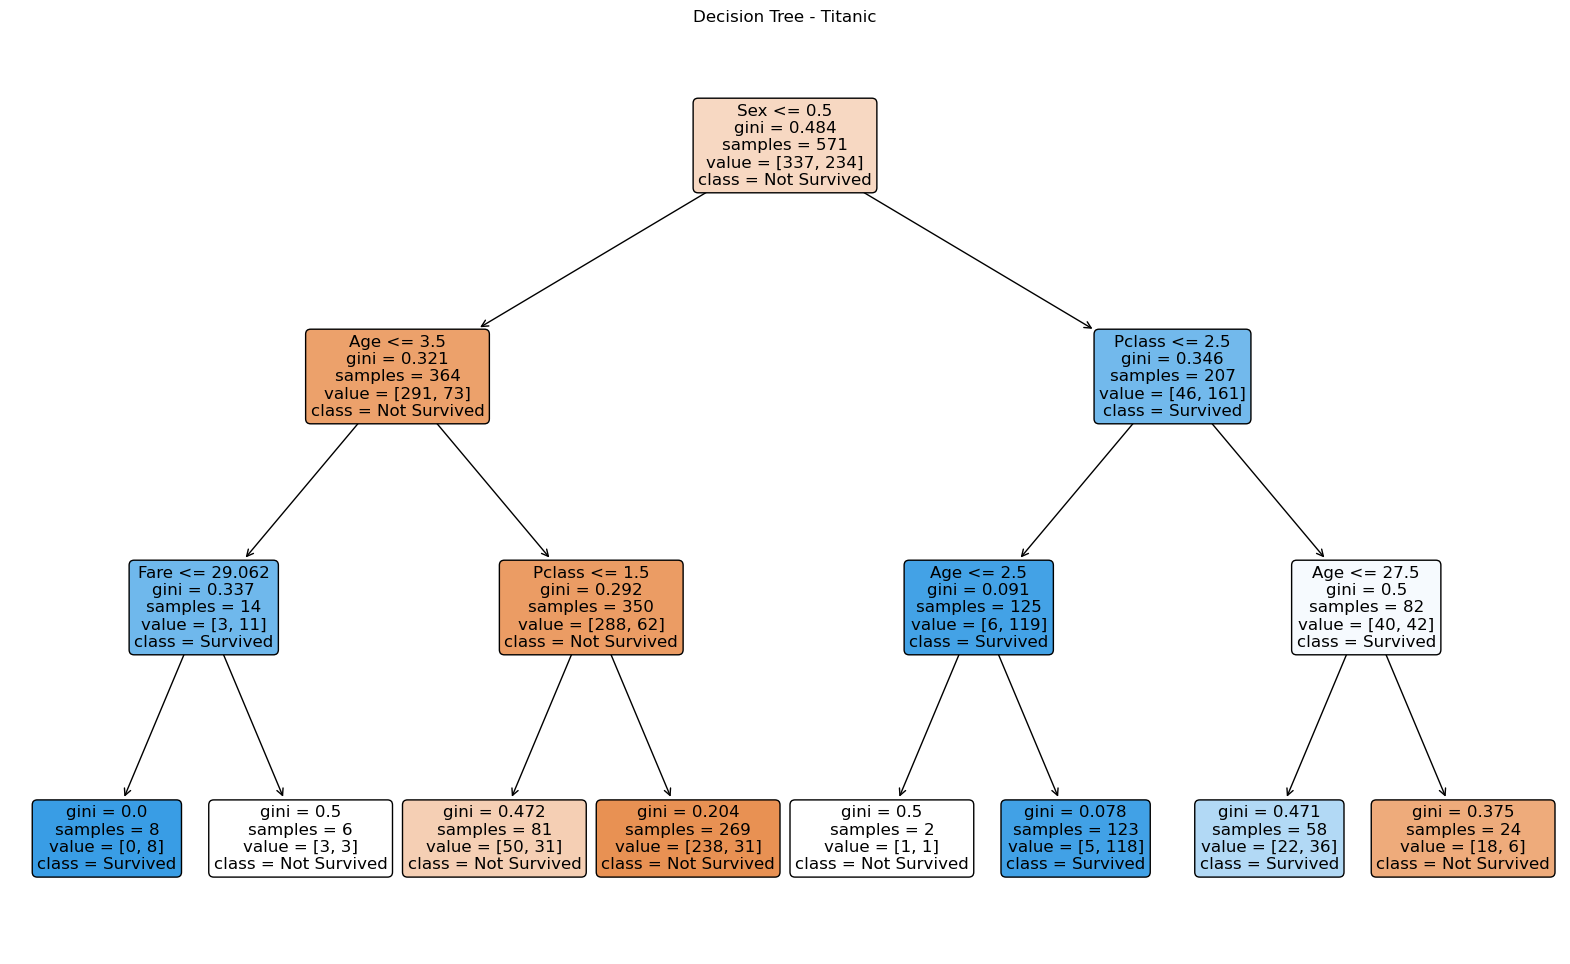

Accuracy: 0.7413
Precision: 0.6939
Recall: 0.6071
F1: 0.6476


In [9]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── 1. Load & Clean ───────────────────────────────────
df = pd.read_csv('titanic.csv')[['Survived','Pclass','Sex','Age','Fare']].dropna()
df['Sex'] = df['Sex'].map({'male':0,'female':1})

# ── 2. Split & Train ──────────────────────────────────
X, y = df[['Pclass','Sex','Age','Fare']], df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)

# ── 3. Plot Tree ──────────────────────────────────────
plt.figure(figsize=(20,12))
plot_tree(clf, feature_names=X.columns, class_names=["Not Survived","Survived"], filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree - Titanic"); plt.show()

# ── 4. Metrics ────────────────────────────────────────
y_pred = clf.predict(X_te)
for name, fn in [("Accuracy",accuracy_score),("Precision",precision_score),("Recall",recall_score),("F1",f1_score)]:
    print(f"{name}: {fn(y_te, y_pred):.4f}")

# exp8

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# ── Load, Train & Predict ─────────────────────────────
data = pd.read_csv('iris.csv')
X, y = data.iloc[:,:-1], data.iloc[:,-1]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

acc = accuracy_score(y_te, GaussianNB().fit(X_tr, y_tr).predict(X_te))
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 97.78%


# EXP9

/home/ai/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f90b9ae5ea0>
Traceback (most recent call last):
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f90b9b11750>
Traceback (most recent call last):
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ai/anaconda3/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


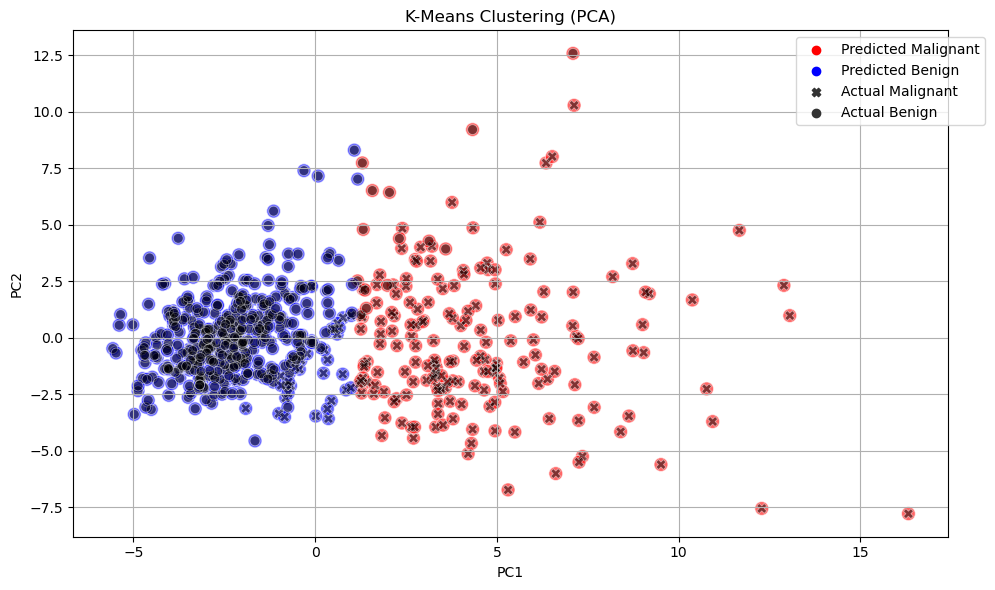

In [11]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mode

# ── 1. Load & Clean ───────────────────────────────────
df  = pd.read_csv("Breast Cancer Wisconsin.csv").drop(columns=['id','Unnamed: 32'], errors='ignore')
diag = df.pop('diagnosis').map({'M':1,'B':0})

# ── 2. Scale, Cluster & PCA ──────────────────────────
scaled  = StandardScaler().fit_transform(df)
labels  = KMeans(n_clusters=2, random_state=42).fit_predict(scaled)
pca_data= PCA(n_components=2).fit_transform(scaled)

# ── 3. Build Plot DataFrame ───────────────────────────
vis = pd.DataFrame({'PCA1':pca_data[:,0],'PCA2':pca_data[:,1],'Cluster':labels,'Actual':diag.values})
cluster_map = {c:('Predicted Malignant' if mode(diag[labels==c],keepdims=True).mode[0]==1 else 'Predicted Benign') for c in [0,1]}
vis['Cluster_Label'] = vis['Cluster'].map(cluster_map)
vis['Actual_Label']  = vis['Actual'].map({1:'Actual Malignant',0:'Actual Benign'})

# ── 4. Plot ───────────────────────────────────────────
plt.figure(figsize=(10,6))
sns.scatterplot(data=vis, x='PCA1', y='PCA2', hue='Cluster_Label',
                palette={'Predicted Malignant':'red','Predicted Benign':'blue'}, s=100, alpha=0.6)
sns.scatterplot(data=vis, x='PCA1', y='PCA2', style='Actual_Label',
                markers={'Actual Malignant':'X','Actual Benign':'o'}, color='black', s=50, alpha=0.5)
plt.title("K-Means Clustering (PCA)"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1)); plt.grid(True); plt.tight_layout(); plt.show()